# 🔥 Wildfire Intelligence System v5.0

## ✅ What's New in v5
| Feature | v4 | v5 |
|---------|----|----|
| Model | EfficientNetB0 | EfficientNetV2S |
| Classes | fire / nofire | fire / smoke / nofire |
| Dataset | 2,700 images | 18,000+ images |
| Grad-CAM | Input gradient (weak) | Feature-level (proper) |
| Augmentation | Basic | Rotation + Zoom + Cutout |
| Risk levels | High / Low | High / Medium / Low |

## ⚡ Quick Start
1. **Runtime → Change runtime type → T4 GPU**
2. Run cells **top to bottom**
3. Combined dataset must already be at `/content/combined_dataset`

## 🔧 Cell 1 — Install Libraries

In [5]:
!pip install -q gradio plotly fpdf2 scikit-image scikit-learn tqdm seaborn
!pip install -q opencv-python-headless Pillow
print("✅ All libraries installed")

✅ All libraries installed


## 📦 Cell 2 — Imports

In [6]:
import os, gc, random, warnings, shutil, datetime, io, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import seaborn as sns
from tqdm import tqdm
from PIL import Image
import psutil

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

print('='*60)
print('🔥 WILDFIRE INTELLIGENCE SYSTEM v5.0'.center(60))
print('='*60)
print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: tf.config.experimental.set_memory_growth(gpus[0], True)
    except: pass
    print(f'GPU        : {gpus[0].name} ✅')
else:
    print('⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU')
print(f'RAM        : {round(psutil.virtual_memory().total/1024**3)} GB')
print('='*60)

            🔥 WILDFIRE INTELLIGENCE SYSTEM v5.0             
TensorFlow : 2.19.0
Keras      : 3.13.2
GPU        : /physical_device:GPU:0 ✅
RAM        : 13 GB


## 📂 Cell 3 — Mount Drive & Extract All Datasets

In [7]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)

# ── Add all your zip files here ──
zips = [
    '/content/drive/MyDrive/THEWILDFIRE.zip',
    '/content/drive/MyDrive/FireSmokeNeutral.zip',
    '/content/drive/MyDrive/ForestFire12k.zip',
    # add more zips here if needed
]

for zip_path in zips:
    if os.path.exists(zip_path):
        print(f'Extracting {os.path.basename(zip_path)}...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_path)
        print(f'✅ Done!')
    else:
        print(f'⚠️  Not found: {zip_path}')

print('\n📁 Dataset structure:')
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 5:
        imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if imgs or (level < 3 and dirs):
            print(f'{"  "*level}📂 {os.path.basename(root) or "dataset"}/  ({len(imgs)} images)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting THEWILDFIRE.zip...
✅ Done!
Extracting FireSmokeNeutral.zip...
✅ Done!
Extracting ForestFire12k.zip...
✅ Done!

📁 Dataset structure:
📂 dataset/  (0 images)
  📂 FIRE-SMOKE-DATASET/  (0 images)
    📂 Test/  (0 images)
      📂 Neutral/  (100 images)
      📂 Smoke/  (100 images)
      📂 Fire/  (100 images)
    📂 Train/  (0 images)
      📂 Neutral/  (900 images)
      📂 Smoke/  (900 images)
      📂 Fire/  (900 images)
  📂 the_wildfire_dataset_2n_version/  (0 images)
    📂 test/  (0 images)
      📂 fire/  (159 images)
      📂 nofire/  (251 images)
    📂 val/  (0 images)
      📂 fire/  (156 images)
      📂 nofire/  (246 images)
    📂 train/  (0 images)
      📂 fire/  (730 images)
      📂 nofire/  (1157 images)
  📂 Forest-Fire-Cleaned/  (0 images)
    📂 Forest-Fire-Cleaned/  (0 images)
        📂 fire/  (553 images)
        📂 nofire/  (688 images)
        📂 

## 🔀 Cell 4 — Merge & Resize All Datasets

In [10]:
import os, cv2
from tqdm import tqdm

SIZE   = (224, 224)
output = '/content/combined_dataset'

# ── Map every possible folder name → unified class ──
class_map = {
    'fire'    : 'fire',    'Fire'    : 'fire',
    'nofire'  : 'nofire',  'noFire'  : 'nofire',
    'no_fire' : 'nofire',  'neutral' : 'nofire',
    'Neutral' : 'nofire',  'nonfire' : 'nofire',
    'smoke'   : 'smoke',   'Smoke'   : 'smoke',
}

for cls in ['fire', 'nofire', 'smoke']:
    os.makedirs(os.path.join(output, cls), exist_ok=True)

counters = {'fire': 0, 'nofire': 0, 'smoke': 0}

# Skip if already merged
total_existing = sum(len(os.listdir(os.path.join(output, c))) for c in ['fire','nofire','smoke'])
if total_existing > 1000:
    print(f'✅ Combined dataset already exists!')
    for cls in ['fire', 'nofire', 'smoke']:
        print(f'   {cls}: {len(os.listdir(os.path.join(output, cls))):,}')
else:
    for root, dirs, files in os.walk('/content/dataset'):
    # Skip the duplicate
        if 'Forest-Fire-Cleaned/' in root and 'V2' not in root:
            continue
        folder_name = os.path.basename(root)
        mapped_cls  = class_map.get(folder_name)
        if mapped_cls is None:
            continue
        imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if not imgs:
            continue
        for f in tqdm(imgs, desc=f'{folder_name}→{mapped_cls}'):
            src = os.path.join(root, f)
            img = cv2.imread(src)
            if img is None: continue
            img = cv2.resize(img, SIZE)
            new_name = f'{mapped_cls}_{counters[mapped_cls]:06d}.jpg'
            dst = os.path.join(output, mapped_cls, new_name)
            cv2.imwrite(dst, img, [cv2.IMWRITE_JPEG_QUALITY, 85])
            counters[mapped_cls] += 1

    print(f'\n✅ Done!')
    for cls, count in counters.items():
        print(f'   {cls}: {count:,} images')

nofire→nofire: 100%|██████████| 2410/2410 [00:06<00:00, 352.37it/s]


✅ Done!
   fire: 4,825 images
   nofire: 6,081 images
   smoke: 1,000 images


## ⚙️ Cell 5 — Config & Class Discovery

In [11]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
data_dir   = '/content/combined_dataset'

image_root  = data_dir
CLASS_NAMES = sorted([d for d in os.listdir(image_root)
                      if os.path.isdir(os.path.join(image_root, d))])
NUM_CLASSES = len(CLASS_NAMES)
print(f'📂 Image root : {image_root}')
print(f'📋 Classes    : {CLASS_NAMES}')
print(f'🔢 Num classes: {NUM_CLASSES}')

# ── Risk map with 3 levels ──
RISK_MAP = {}
for c in CLASS_NAMES:
    cl = c.lower().replace('_','').replace('-','').replace(' ','')
    if any(x in cl for x in ['nofire','nowildfire','nonfire','safe','neutral','normal']):
        RISK_MAP[c] = 'Low Risk'
    elif any(x in cl for x in ['smoke']):
        RISK_MAP[c] = 'Medium Risk'
    elif any(x in cl for x in ['fire','burn','flame','blaze','wildfire','hot']):
        RISK_MAP[c] = 'High Risk'
    else:
        RISK_MAP[c] = 'Low Risk'

print('\n🗺️  Risk mapping:')
for c, r in RISK_MAP.items():
    icon = '🔴' if r == 'High Risk' else '🟡' if r == 'Medium Risk' else '🟢'
    print(f'   {icon} {c:25s} → {r}')

📂 Image root : /content/combined_dataset
📋 Classes    : ['fire', 'nofire', 'smoke']
🔢 Num classes: 3

🗺️  Risk mapping:
   🔴 fire                      → High Risk
   🟢 nofire                    → Low Risk
   🟡 smoke                     → Medium Risk


## 📊 Cell 6 — Build File Lists & Split

In [12]:
all_paths, all_labels = [], []
print('\n📊 Image counts:')
for idx, cls in enumerate(CLASS_NAMES):
    d    = os.path.join(image_root, cls)
    imgs = [os.path.join(d, f) for f in os.listdir(d)
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f'   {cls:25s}: {len(imgs):,}')
    all_paths  += imgs
    all_labels += [idx] * len(imgs)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)

p_train,p_temp,l_train,l_temp = train_test_split(
    all_paths, all_labels, test_size=0.3, random_state=42, stratify=all_labels)
p_val,p_test,l_val,l_test = train_test_split(
    p_temp, l_temp, test_size=0.5, random_state=42, stratify=l_temp)

print(f'\n✅ Train: {len(p_train):,}  Val: {len(p_val):,}  Test: {len(p_test):,}')


📊 Image counts:
   fire                     : 4,825
   nofire                   : 6,081
   smoke                    : 1,000

✅ Train: 8,334  Val: 1,786  Test: 1,786


## 🖼️ Cell 7 — Sample Visualization

  fire: 4,825 images
  nofire: 6,081 images
  smoke: 1,000 images


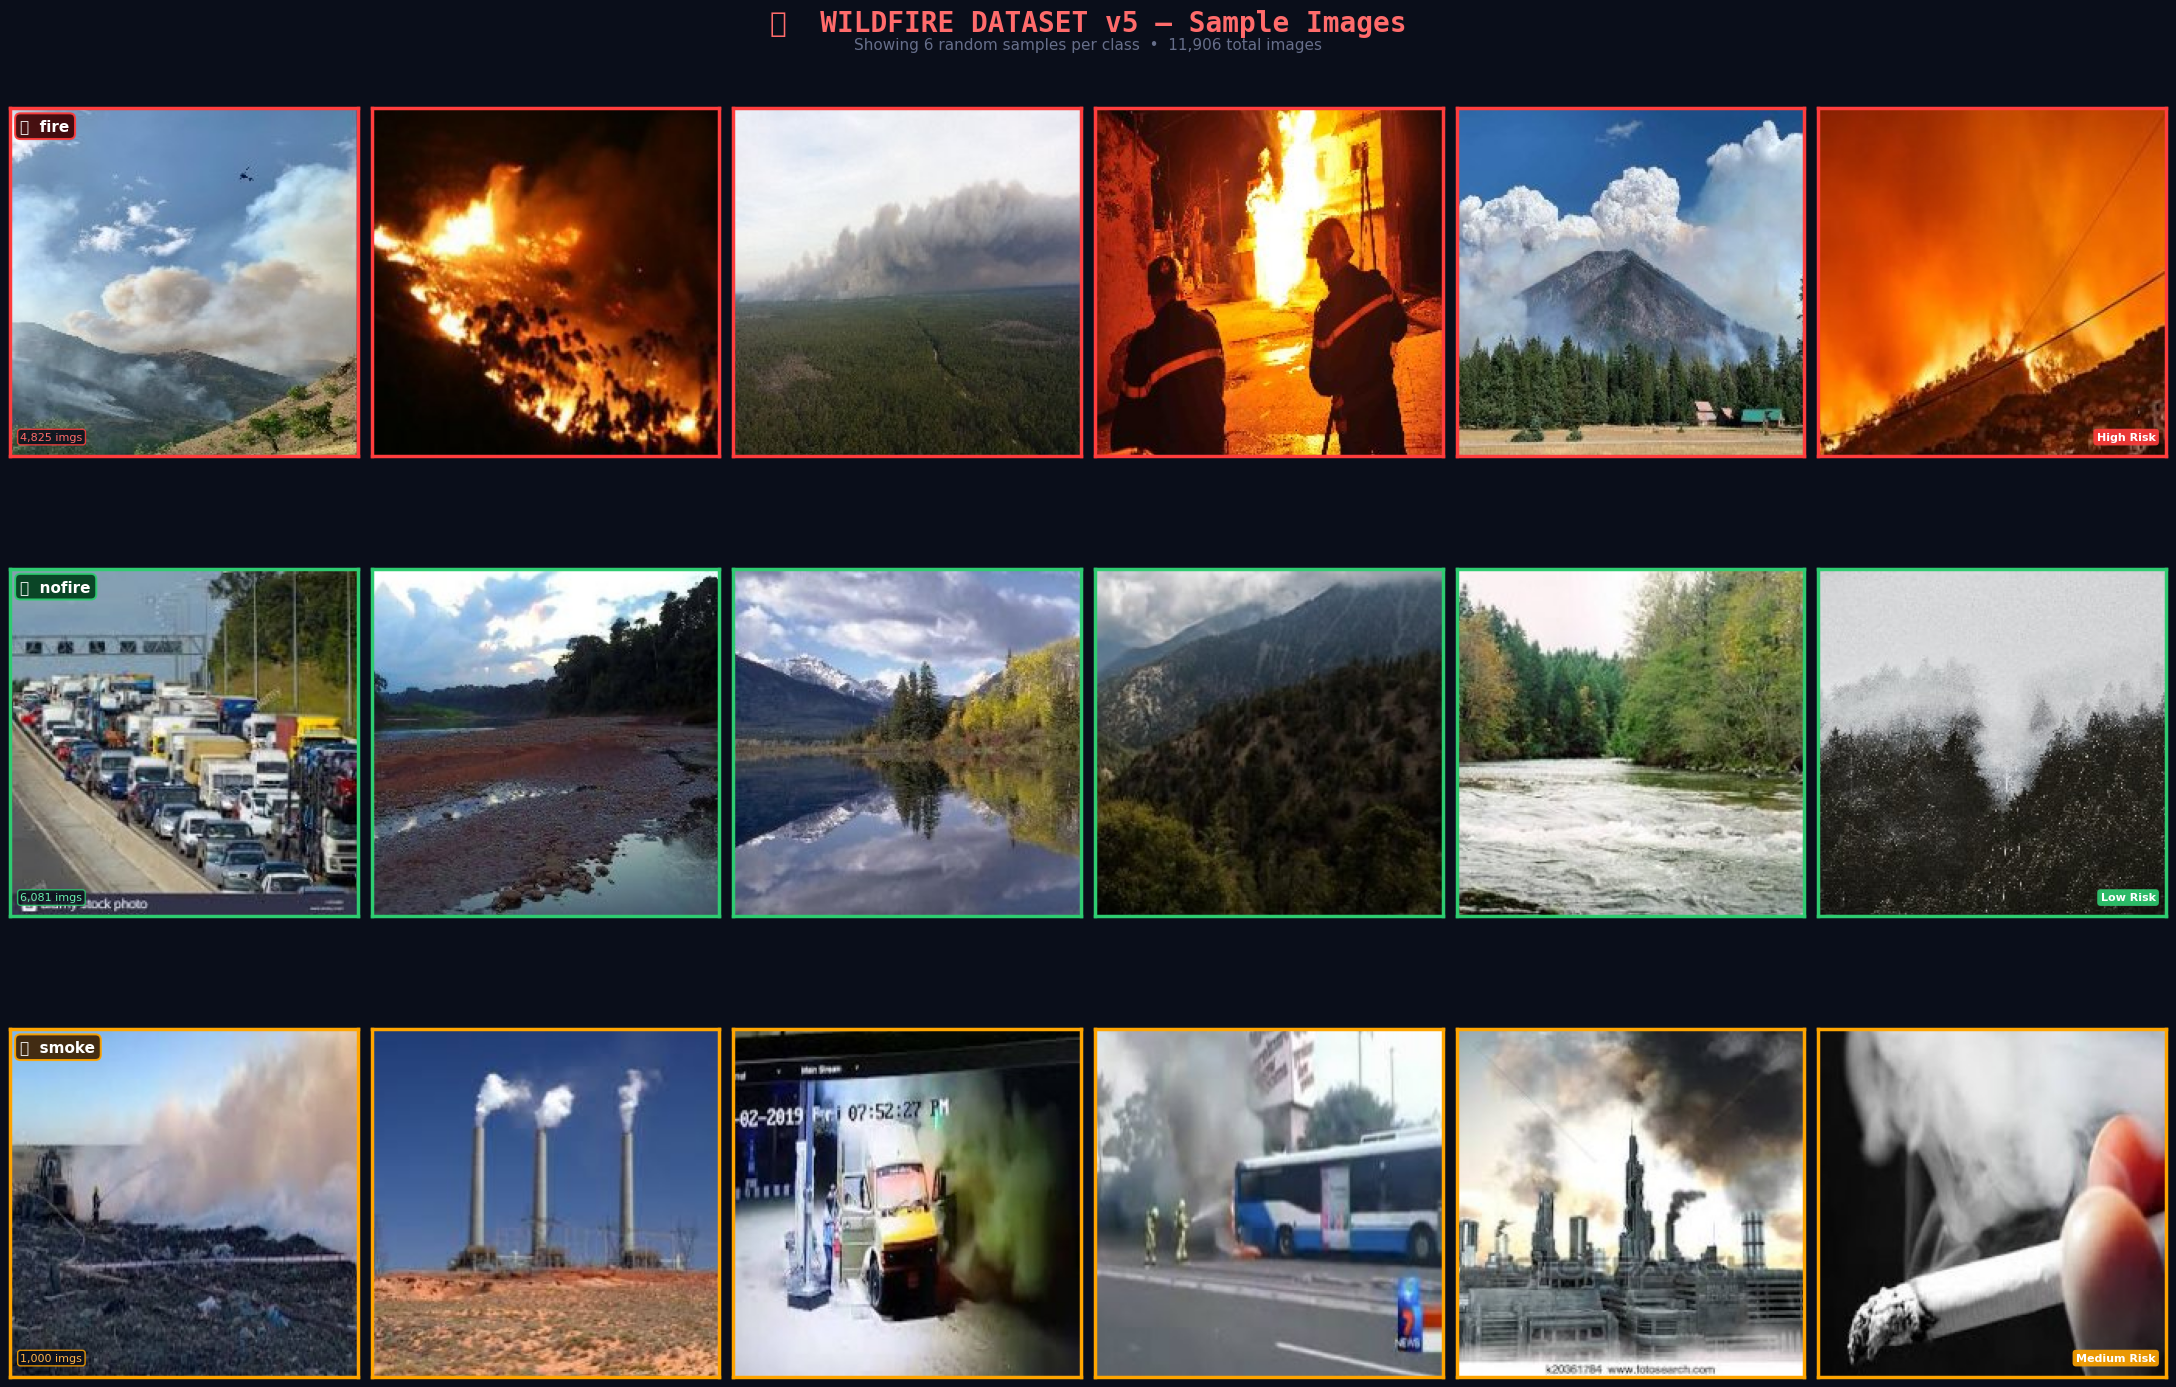

✅ Sample grid saved


In [13]:
import math

def load_img_display(path):
    img = cv2.imread(path)
    if img is None: return np.zeros((*IMG_SIZE,3), dtype=np.uint8)
    return cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), IMG_SIZE)

class_paths = {}
for c in CLASS_NAMES:
    folder = os.path.join(image_root, c)
    files  = [os.path.join(folder, f) for f in os.listdir(folder)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]
    class_paths[c] = files
    print(f'  {c}: {len(files):,} images')

N_COLS = 6
N_ROWS = len(CLASS_NAMES)

CARD_COLORS = {
    'High Risk'  : {'border': '#FF3D3D', 'title_bg': '#3D0000', 'title_fg': '#FF6B6B', 'badge': '#FF3D3D', 'icon': '🔥'},
    'Medium Risk': {'border': '#FFA500', 'title_bg': '#3D2000', 'title_fg': '#FFB347', 'badge': '#FFA500', 'icon': '💨'},
    'Low Risk'   : {'border': '#2ECC71', 'title_bg': '#003D1A', 'title_fg': '#69F0AE', 'badge': '#2ECC71', 'icon': '🌿'},
}

fig = plt.figure(figsize=(22, N_ROWS*4.2+1.5), facecolor='#0A0E1A')
fig.text(0.5, 0.995, '🔥  WILDFIRE DATASET v5 — Sample Images',
         ha='center', va='top', fontsize=20, fontweight='bold',
         color='#FF6B6B', fontfamily='monospace')
fig.text(0.5, 0.975,
         f'Showing {N_COLS} random samples per class  •  {sum(len(v) for v in class_paths.values()):,} total images',
         ha='center', va='top', fontsize=11, color='#666E8A')

gs = fig.add_gridspec(N_ROWS, N_COLS, top=0.94, bottom=0.01,
                      left=0.01, right=0.99, hspace=0.18, wspace=0.04)

for row, cls in enumerate(CLASS_NAMES):
    risk   = RISK_MAP.get(cls, 'Low Risk')
    colors = CARD_COLORS[risk]
    samples = random.sample(class_paths[cls], min(N_COLS, len(class_paths[cls])))
    for col in range(N_COLS):
        ax = fig.add_subplot(gs[row, col])
        if col < len(samples):
            ax.imshow(load_img_display(samples[col]))
        else:
            ax.set_facecolor('#111827')
        for spine in ax.spines.values():
            spine.set_edgecolor(colors['border']); spine.set_linewidth(2.5)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.text(0.03, 0.97, f"{colors['icon']}  {cls}",
                    transform=ax.transAxes, va='top', ha='left',
                    fontsize=11, fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.35', facecolor=colors['title_bg'],
                              edgecolor=colors['border'], linewidth=1.5, alpha=0.92))
            ax.text(0.03, 0.04, f'{len(class_paths[cls]):,} imgs',
                    transform=ax.transAxes, va='bottom', ha='left',
                    fontsize=8, color=colors['title_fg'],
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='#0A0E1A',
                              edgecolor=colors['border'], linewidth=1, alpha=0.85))
        if col == N_COLS-1:
            ax.text(0.97, 0.04, risk, transform=ax.transAxes,
                    va='bottom', ha='right', fontsize=8, fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=colors['badge'],
                              edgecolor='none', alpha=0.9))

plt.savefig('/content/samples.png', dpi=140, bbox_inches='tight',
            facecolor='#0A0E1A', edgecolor='none')
plt.show()
print('✅ Sample grid saved')

## 🚀 Cell 8 — PyDataset with Better Augmentation

In [14]:
class WildfireDataset(keras.utils.PyDataset):
    def __init__(self, paths, labels, batch_size=32,
                 augment=False, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.paths      = np.array(paths)
        self.labels     = np.array(labels, dtype=np.int32)
        self.batch_size = batch_size
        self.augment    = augment
        self.shuffle    = shuffle
        self.indices    = np.arange(len(self.paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    @staticmethod
    def _load(path):
        img = cv2.imread(path)
        if img is None:
            return np.zeros((*IMG_SIZE, 3), dtype=np.float32)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        img = img.astype(np.float32)
        img = (img / 127.5) - 1.0   # EfficientNetV2 range [-1, 1]
        return img

    @staticmethod
    def _augment(img):
        # Horizontal flip
        if random.random() > 0.5:
            img = img[:, ::-1, :]
        # Vertical flip
        if random.random() > 0.3:
            img = img[::-1, :, :]
        # Brightness jitter
        delta = random.uniform(-0.2, 0.2)
        img   = np.clip(img + delta, -1.0, 1.0)
        # Contrast jitter
        factor = random.uniform(0.8, 1.2)
        img    = np.clip(img * factor, -1.0, 1.0)
        # Random rotation (small)
        if random.random() > 0.5:
            angle = random.uniform(-15, 15)
            h, w  = img.shape[:2]
            M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
            img_u = ((img + 1.0) * 127.5).astype(np.uint8)
            img_u = cv2.warpAffine(img_u, M, (w, h))
            img   = (img_u.astype(np.float32) / 127.5) - 1.0
        # Cutout — random black patch
        if random.random() > 0.5:
            h, w  = img.shape[:2]
            ch, cw = h//5, w//5
            y = random.randint(0, h-ch)
            x = random.randint(0, w-cw)
            img[y:y+ch, x:x+cw, :] = 0.0
        return img

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        imgs, lbls = [], []
        for i in batch_idx:
            img = self._load(self.paths[i])
            if self.augment:
                img = self._augment(img)
            imgs.append(img)
            lbls.append(self.labels[i])
        return np.array(imgs, dtype=np.float32), np.array(lbls, dtype=np.int32)

train_gen = WildfireDataset(p_train, l_train, BATCH_SIZE, augment=True,  shuffle=True)
val_gen   = WildfireDataset(p_val,   l_val,   BATCH_SIZE, augment=False, shuffle=False)
test_gen  = WildfireDataset(p_test,  l_test,  BATCH_SIZE, augment=False, shuffle=False)

imgs_b, lbls_b = train_gen[0]
print(f'✅ imgs: {imgs_b.shape}  dtype={imgs_b.dtype}  min={imgs_b.min():.2f}  max={imgs_b.max():.2f}')
print(f'✅ lbls: {lbls_b.shape}  dtype={lbls_b.dtype}')

cw = compute_class_weight('balanced', classes=np.unique(l_train), y=l_train)
class_weight_dict = {int(k): float(v) for k, v in enumerate(cw)}
print(f'\nClass weights: {dict((CLASS_NAMES[k],round(v,3)) for k,v in class_weight_dict.items())}')

✅ imgs: (32, 224, 224, 3)  dtype=float32  min=-1.00  max=1.00
✅ lbls: (32,)  dtype=int32

Class weights: {'fire': 0.823, 'nofire': 0.653, 'smoke': 3.969}


## 🏗️ Cell 9 — Build EfficientNetV2S Classifier

In [15]:
def build_classifier(num_classes):
    # ── Flat architecture — EfficientNetV2S NOT nested ──
    base = EfficientNetV2S(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3),
        include_preprocessing=False
    )
    base.trainable = False

    # ── Use base.input and base.output directly — NO nesting ──
    x   = base.output
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(512, activation='relu',
                       kernel_regularizer=keras.regularizers.l2(1e-3))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(256, activation='relu',
                       kernel_regularizer=keras.regularizers.l2(1e-3))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs=base.input, outputs=out)

    # Find last conv layer — now directly accessible
    last_conv = None
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            last_conv = layer
            break
    print(f'✅ Last conv layer: {last_conv.name}  shape: {last_conv.output.shape}')

    return model, base, last_conv.name

risk_model, base_model, LAST_CONV_LAYER = build_classifier(NUM_CLASSES)
risk_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print(f'✅ Model built — flat architecture, Grad-CAM ready')

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✅ Last conv layer: top_conv  shape: (None, 7, 7, 1280)
✅ Model built — flat architecture, Grad-CAM ready


## 🔥 Cell 10 — Phase 1: Train Top Layers (Frozen Backbone)

In [16]:
print('🚀 Phase 1: training top layers (backbone frozen) ...')

cb1 = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_phase1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

h1 = risk_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=cb1,
    verbose=1
)

print(f'\n✅ Phase 1 complete!')
print(f'   Best val accuracy : {max(h1.history["val_accuracy"]):.2%}')
print(f'   Final train acc   : {h1.history["accuracy"][-1]:.2%}')

🚀 Phase 1: training top layers (backbone frozen) ...
Epoch 1/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7577 - loss: 1.8012
Epoch 1: val_accuracy improved from None to 0.90202, saving model to /content/best_phase1.keras

Epoch 1: finished saving model to /content/best_phase1.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 157s 361ms/step - accuracy: 0.8045 - loss: 1.6798 - val_accuracy: 0.9020 - val_loss: 1.3477 - learning_rate: 0.0010
Epoch 2/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8386 - loss: 1.4827
Epoch 2: val_accuracy improved from 0.90202 to 0.91881, saving model to /content/best_phase1.keras

Epoch 2: finished saving model to /content/best_phase1.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 34s 128ms/step - accuracy: 0.8456 - loss: 1.4367 - val_accuracy: 0.9188 - val_loss: 1.2215 - learning_rate: 0.0010
Epoch 3/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8687 - loss: 1.3112
Epoch 3: val_accuracy did not improve from 0.91881
261/261 ━━━━━━━━━━━━━━━━━

## 🔥 Cell 11 — Phase 2: Fine-Tune Full Network

🚀 Phase 2: fine-tuning full network ...
Epoch 1/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.8090 - loss: 1.0602
Epoch 1: val_accuracy improved from None to 0.90761, saving model to /content/best_final.keras

Epoch 1: finished saving model to /content/best_final.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 373s 772ms/step - accuracy: 0.8408 - loss: 0.9719 - val_accuracy: 0.9076 - val_loss: 0.7920 - learning_rate: 5.0000e-05
Epoch 2/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.8908 - loss: 0.8070
Epoch 2: val_accuracy improved from 0.90761 to 0.92889, saving model to /content/best_final.keras

Epoch 2: finished saving model to /content/best_final.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 102s 390ms/step - accuracy: 0.8994 - loss: 0.7876 - val_accuracy: 0.9289 - val_loss: 0.7207 - learning_rate: 5.0000e-05
Epoch 3/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9204 - loss: 0.7284
Epoch 3: val_accuracy improved from 0.92889 to 0.93673, saving model to /content/be

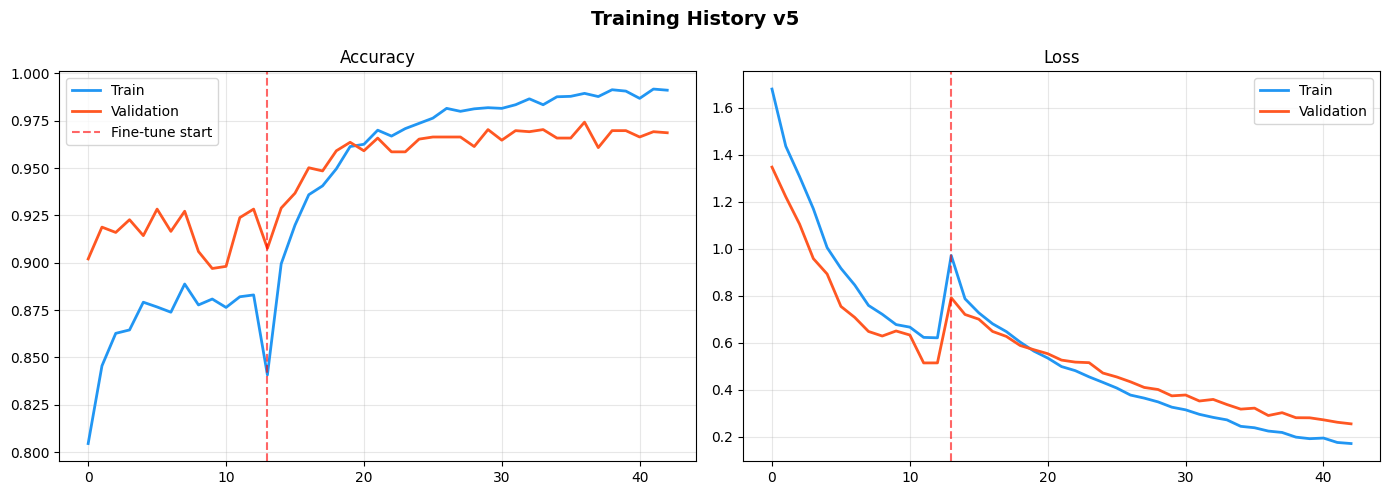


✅ Phase 2 complete!
   Best val accuracy : 97.42%
   Best val loss     : 0.2555


In [17]:
print('🚀 Phase 2: fine-tuning full network ...')

base_model.trainable = True
risk_model.compile(
    optimizer=Adam(learning_rate=5e-5),   # lower LR for stable fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb2 = [
    EarlyStopping(monitor='val_accuracy', patience=12,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=6, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_final.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

h2 = risk_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=cb2,
    verbose=1
)

risk_model.save('/content/risk_model_final.keras')

all_acc      = h1.history['accuracy']     + h2.history['accuracy']
all_val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
all_loss     = h1.history['loss']         + h2.history['loss']
all_val_loss = h1.history['val_loss']     + h2.history['val_loss']
ep1 = len(h1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History v5', fontsize=14, fontweight='bold')
ax1.plot(all_acc,     label='Train',      color='#2196F3', lw=2)
ax1.plot(all_val_acc, label='Validation', color='#FF5722', lw=2)
ax1.axvline(ep1, color='red', ls='--', alpha=0.6, label='Fine-tune start')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(all_loss,     label='Train',      color='#2196F3', lw=2)
ax2.plot(all_val_loss, label='Validation', color='#FF5722', lw=2)
ax2.axvline(ep1, color='red', ls='--', alpha=0.6)
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

print(f'\n✅ Phase 2 complete!')
print(f'   Best val accuracy : {max(all_val_acc):.2%}')
print(f'   Best val loss     : {min(all_val_loss):.4f}')

## 📊 Cell 12 — Full Evaluation

Evaluating on test set...


Evaluating: 100%|██████████| 56/56 [00:49<00:00,  1.14it/s]



✅ Test Accuracy: 97.26%

📋 Per-class performance:
   🔴 fire                     : 96.55% ✅
   🟢 nofire                   : 97.81% ✅
   🟡 smoke                    : 97.33% ✅

              precision    recall  f1-score   support

        fire       0.97      0.97      0.97       724
      nofire       0.98      0.98      0.98       912
       smoke       0.94      0.97      0.95       150

    accuracy                           0.97      1786
   macro avg       0.96      0.97      0.97      1786
weighted avg       0.97      0.97      0.97      1786



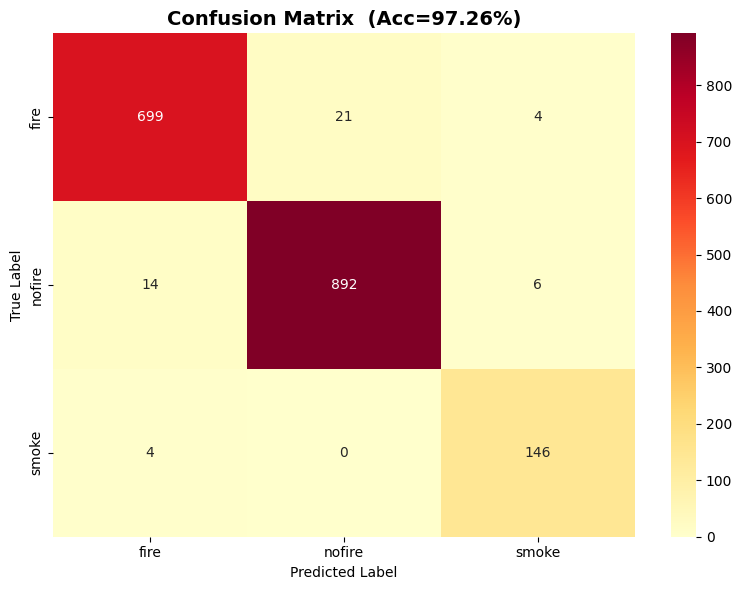

✅ Confusion matrix saved


In [18]:
best_model = keras.models.load_model('/content/best_final.keras')

print('Evaluating on test set...')
y_true, y_pred, y_proba = [], [], []

for i in tqdm(range(len(test_gen)), desc='Evaluating'):
    imgs_b, lbls_b = test_gen[i]
    preds = best_model.predict(imgs_b, verbose=0)
    y_true.extend(lbls_b.tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())
    y_proba.extend(preds.tolist())

y_true  = np.array(y_true)
y_pred  = np.array(y_pred)
y_proba = np.array(y_proba)

accuracy = np.mean(y_true == y_pred)
print(f'\n✅ Test Accuracy: {accuracy:.2%}')

print('\n📋 Per-class performance:')
for i, cls in enumerate(CLASS_NAMES):
    mask = y_true == i
    if mask.sum() == 0: continue
    cacc = (y_pred[mask] == i).mean()
    risk = RISK_MAP[cls]
    icon = '🔴' if risk=='High Risk' else '🟡' if risk=='Medium Risk' else '🟢'
    flag = '✅' if cacc>=0.85 else '⚠️' if cacc>=0.70 else '❌'
    print(f'   {icon} {cls:25s}: {cacc:.2%} {flag}')

print('\n' + classification_report(y_true, y_pred, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES*2.5), max(6, NUM_CLASSES*2)))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f'Confusion Matrix  (Acc={accuracy:.2%})', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print('✅ Confusion matrix saved')

## 🔍 Cell 13 — Proper Feature-Level Grad-CAM

✅ Grad-CAM ready!


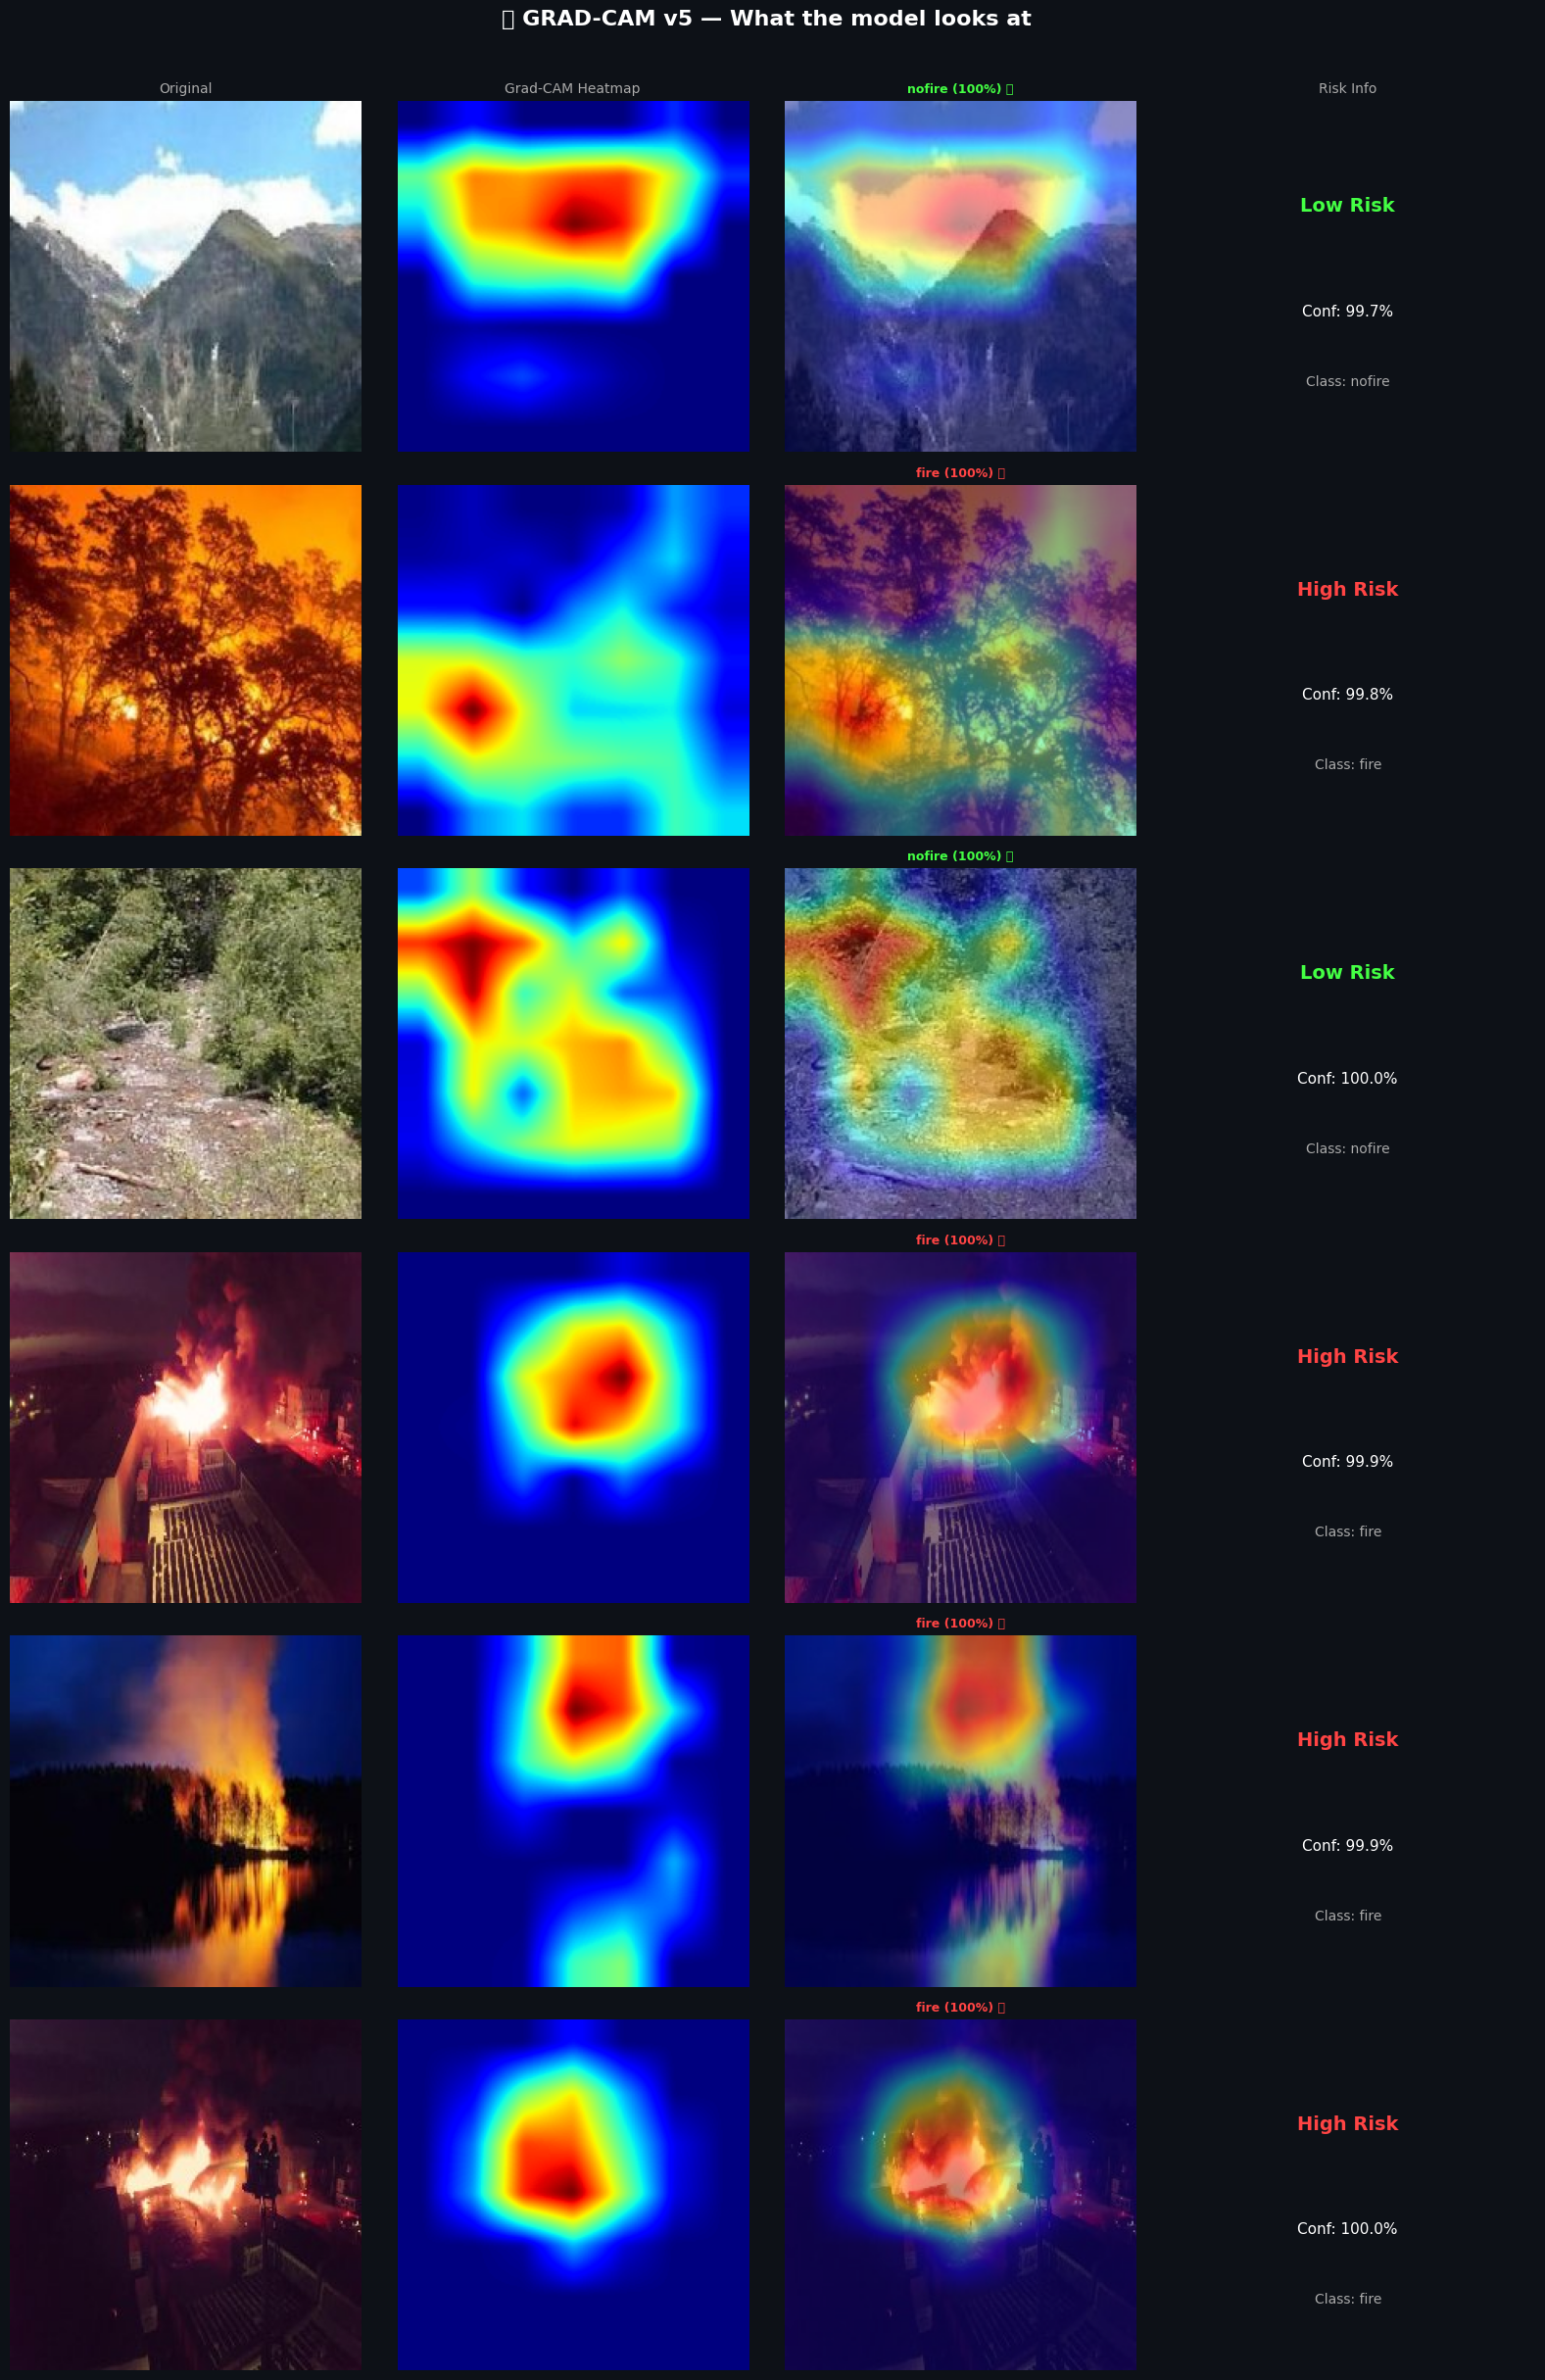

✅ Grad-CAM saved!


In [21]:
def get_gradcam(img_float_minus1_1):
    inp = tf.cast(img_float_minus1_1[np.newaxis], tf.float32)

    # Single model, last conv directly accessible — no nesting!
    grad_model = keras.Model(
        inputs  = best_model.input,
        outputs = [best_model.get_layer(LAST_CONV_LAYER).output, best_model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(inp, training=False)
        tape.watch(conv_out)
        class_idx = int(tf.argmax(preds[0]))
        loss = preds[:, class_idx]

    grads   = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam     = tf.reduce_sum(conv_out[0] * weights, axis=-1)
    cam     = tf.nn.relu(cam).numpy()
    if cam.max() > 0:
        cam = cam / cam.max()
    cam = cv2.resize(cam, IMG_SIZE)
    cam = cv2.GaussianBlur(cam, (11, 11), 0)
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam, class_idx

print('✅ Grad-CAM ready!')
def apply_colormap_overlay(orig_uint8, heatmap, alpha=0.45):
    orig_uint8 = np.squeeze(orig_uint8)
    jet   = cv2.applyColorMap((heatmap*255).astype(np.uint8), cv2.COLORMAP_JET)
    jet   = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB)
    blend = np.clip(orig_uint8*(1-alpha) + jet*alpha, 0, 255).astype(np.uint8)
    return blend

# ── Test on 6 random samples ──
sample_idxs = np.random.choice(len(p_test), 6, replace=False)
fig, axes   = plt.subplots(6, 4, figsize=(16, 24))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('🔥 GRAD-CAM v5 — What the model looks at',
             color='white', fontsize=16, fontweight='bold', y=1.01)

cols = ['Original', 'Grad-CAM Heatmap', 'CAM Overlay', 'Risk Info']
for ax, c in zip(axes[0], cols):
    ax.set_title(c, color='#aaaaaa', fontsize=10)

for row, si in enumerate(sample_idxs):
    raw    = cv2.imread(p_test[si])
    raw    = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    raw    = cv2.resize(raw, IMG_SIZE)
    inp    = ((raw.astype(np.float32) / 127.5) - 1.0)

    pred    = best_model.predict(inp[np.newaxis], verbose=0)[0]
    ci      = int(np.argmax(pred))
    conf    = pred[ci]
    name    = CLASS_NAMES[ci]
    risk    = RISK_MAP[name]
    true_n  = CLASS_NAMES[l_test[si]]
    correct = (ci == l_test[si])
    rc      = '#ff4444' if risk=='High Risk' else '#FFA500' if risk=='Medium Risk' else '#44ff44'

    hmap, _ = get_gradcam(inp)
    overlay = apply_colormap_overlay(raw, hmap)

    axes[row,0].imshow(raw)
    axes[row,0].set_ylabel(f'True: {true_n}', color='white', fontsize=8, rotation=0, labelpad=80)
    axes[row,0].axis('off')
    axes[row,1].imshow(hmap, cmap='jet', vmin=0, vmax=1)
    axes[row,1].axis('off')
    axes[row,2].imshow(overlay)
    axes[row,2].set_title(f'{name} ({conf:.0%}) {"✅" if correct else "❌"}',
                          color=rc, fontsize=9, fontweight='bold')
    axes[row,2].axis('off')
    axes[row,3].set_facecolor('#111827')
    axes[row,3].text(0.5, 0.7, risk, ha='center', va='center',
                     fontsize=14, fontweight='bold', color=rc,
                     transform=axes[row,3].transAxes)
    axes[row,3].text(0.5, 0.4, f'Conf: {conf:.1%}', ha='center', va='center',
                     fontsize=11, color='white', transform=axes[row,3].transAxes)
    axes[row,3].text(0.5, 0.2, f'Class: {name}', ha='center', va='center',
                     fontsize=10, color='#aaaaaa', transform=axes[row,3].transAxes)
    axes[row,3].axis('off')

for ax in axes.flat:
    ax.set_facecolor('#0d1117')

plt.tight_layout()
plt.savefig('/content/gradcam_results.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Grad-CAM saved!')

## 🏗️ Cell 14 — Build U-Net Segmentation Model

In [22]:
def build_unet(input_size=(224, 224, 3)):
    inp = keras.Input(input_size)

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        return x

    c1 = conv_block(inp, 64);  p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1,  128); p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2,  256); p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3,  512); p4 = layers.MaxPooling2D()(c4)
    bn = conv_block(p4, 1024)

    def up_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, filters)
        return x

    u4 = up_block(bn, c4, 512)
    u3 = up_block(u4, c3, 256)
    u2 = up_block(u3, c2, 128)
    u1 = up_block(u2, c1,  64)
    out = layers.Conv2D(1, 1, activation='sigmoid', name='seg_output')(u1)
    return keras.Model(inp, out, name='UNet')

unet_model = build_unet()

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2.*intersection+smooth) / (tf.reduce_sum(y_true_f)+tf.reduce_sum(y_pred_f)+smooth)

def combined_loss(y_true, y_pred):
    return 0.5*keras.losses.binary_crossentropy(y_true, y_pred) + 0.5*dice_loss(y_true, y_pred)

unet_model.compile(optimizer=Adam(1e-3), loss=combined_loss, metrics=['accuracy'])
print(f'✅ U-Net built: {unet_model.count_params():,} params')

✅ U-Net built: 31,055,297 params


## 🎭 Cell 15 — Train U-Net with Grad-CAM Masks

In [23]:
# ════════════════════════════════════════════════════════════════
# Using Grad-CAM as pseudo-masks — much better than HSV
# Fire images  → Grad-CAM heatmap as mask
# Smoke images → Grad-CAM heatmap as mask
# Nofire images → all-zero mask
# ════════════════════════════════════════════════════════════════

def create_gradcam_mask(path, cls_name):
    img = cv2.imread(path)
    if img is None:
        return np.zeros((*IMG_SIZE,), dtype=np.float32)
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, IMG_SIZE)

    if cls_name == 'nofire':
        return np.zeros((*IMG_SIZE,), dtype=np.float32)

    inp  = ((img.astype(np.float32) / 127.5) - 1.0)
    cam, _ = get_gradcam(((img.astype(np.float32) / 127.5) - 1.0))

    # Threshold — keep top 40% activations
    threshold = np.percentile(cam, 60)
    mask = np.where(cam > threshold, cam, 0).astype(np.float32)
    if mask.max() > 0:
        mask = mask / mask.max()
    return mask

print('Building Grad-CAM segmentation dataset (up to 1500 images)...')

# Use fire and smoke images for masks + some nofire
fire_paths  = [p for p, l in zip(all_paths, all_labels)
               if CLASS_NAMES[l] in ['fire', 'smoke']][:750]
nofire_paths = [p for p, l in zip(all_paths, all_labels)
                if CLASS_NAMES[l] == 'nofire'][:750]
seg_paths   = fire_paths + nofire_paths
seg_classes = ([CLASS_NAMES[all_labels[list(all_paths).index(p)]] for p in fire_paths] +
               ['nofire'] * len(nofire_paths))

X_seg, y_seg = [], []
for path, cls_name in tqdm(zip(seg_paths, seg_classes), total=len(seg_paths)):
    img = cv2.imread(path)
    if img is None: continue
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, IMG_SIZE).astype(np.float32) / 255.0
    mask = create_gradcam_mask(path, cls_name)
    X_seg.append(img)
    y_seg.append(mask)

X_seg = np.array(X_seg, dtype=np.float32)
y_seg = np.expand_dims(np.array(y_seg, dtype=np.float32), -1)
print(f'Dataset: {X_seg.shape}  masks: {y_seg.shape}')

Xtr,Xte,ytr,yte = train_test_split(X_seg, y_seg, test_size=0.2,  random_state=42)
Xtr,Xv, ytr,yv  = train_test_split(Xtr,   ytr,   test_size=0.15, random_state=42)
print(f'Train:{len(Xtr)}  Val:{len(Xv)}  Test:{len(Xte)}')

print('\n🚀 Training U-Net...')
unet_cb = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_unet.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

h_unet = unet_model.fit(
    Xtr, ytr, validation_data=(Xv, yv),
    epochs=30, batch_size=16, callbacks=unet_cb, verbose=1
)
unet_model.save('/content/unet_final.keras')
print('✅ U-Net training complete!')

Building Grad-CAM segmentation dataset (up to 1500 images)...


100%|██████████| 1500/1500 [18:16<00:00,  1.37it/s] 


Dataset: (1500, 224, 224, 3)  masks: (1500, 224, 224, 1)
Train:1020  Val:180  Test:300

🚀 Training U-Net...
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5796 - loss: 0.7480   
Epoch 1: val_loss improved from None to 3096.08203, saving model to /content/best_unet.keras

Epoch 1: finished saving model to /content/best_unet.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 257s 3s/step - accuracy: 0.6516 - loss: 0.6839 - val_accuracy: 5.6025e-05 - val_loss: 3096.0820 - learning_rate: 0.0010
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.7357 - loss: 0.5766
Epoch 2: val_loss improved from 3096.08203 to 42.91056, saving model to /content/best_unet.keras

Epoch 2: finished saving model to /content/best_unet.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.7466 - loss: 0.5545 - val_accuracy: 5.3877e-04 - val_loss: 42.9106 - learning_rate: 0.0010
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.7658 - loss: 0.4951
Epoch 3: val_loss improved from 4

## 🧪 Cell 16 — U-Net Segmentation Results

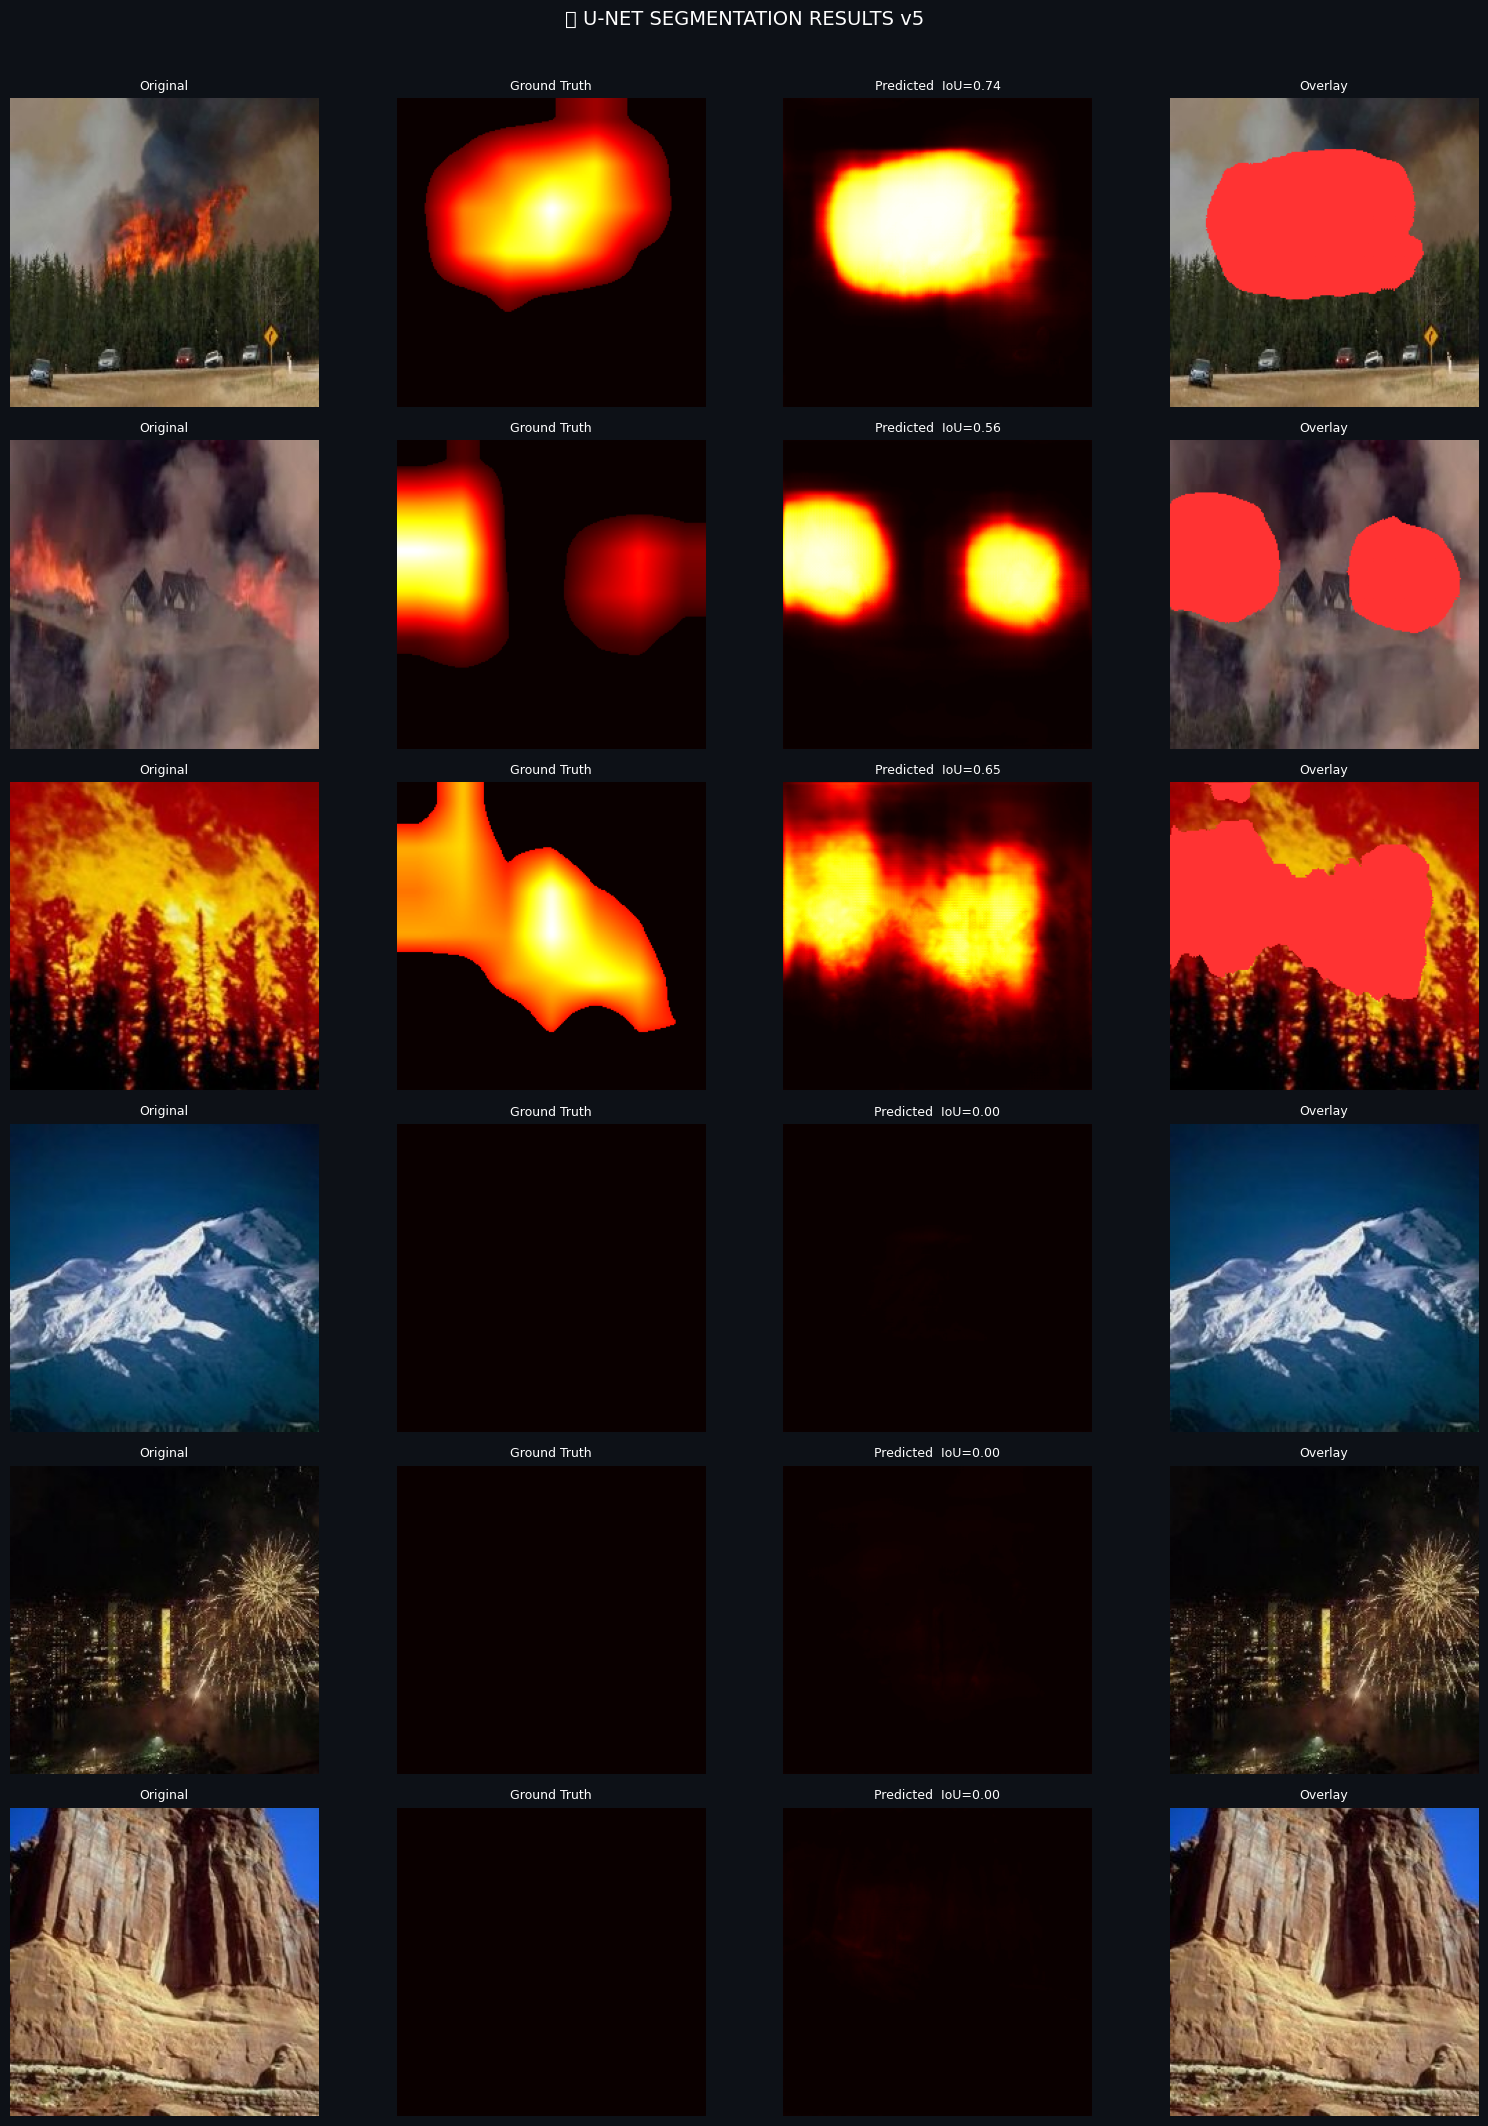

✅ U-Net test complete


In [24]:
unet_model = keras.models.load_model('/content/best_unet.keras',
                                     custom_objects={'combined_loss': combined_loss})

n   = min(6, len(Xte))
idx = np.random.choice(len(Xte), n, replace=False)
fig, axes = plt.subplots(n, 4, figsize=(16, n*3.5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('🔥 U-NET SEGMENTATION RESULTS v5', color='white', fontsize=14, y=1.01)
if n==1: axes=[axes]

for i, si in enumerate(idx):
    img       = Xte[si]
    true_mask = yte[si,:,:,0]
    pred_mask = unet_model.predict(img[np.newaxis], verbose=0)[0,:,:,0]
    binary    = (pred_mask > 0.3).astype(float)
    iou = (np.sum((binary>0.5)&(true_mask>0.3)) /
           (np.sum((binary>0.5)|(true_mask>0.3))+1e-6))

    axes[i][0].imshow(img);       axes[i][0].set_title('Original', color='w', fontsize=9);       axes[i][0].axis('off')
    axes[i][1].imshow(true_mask, cmap='hot', vmin=0, vmax=1)
    axes[i][1].set_title(f'Ground Truth', color='w', fontsize=9);  axes[i][1].axis('off')
    axes[i][2].imshow(pred_mask, cmap='hot', vmin=0, vmax=1)
    axes[i][2].set_title(f'Predicted  IoU={iou:.2f}', color='w', fontsize=9); axes[i][2].axis('off')
    ov = img.copy(); ov[binary>0.5] = [1, 0.2, 0.2]
    axes[i][3].imshow(ov);        axes[i][3].set_title('Overlay', color='w', fontsize=9);        axes[i][3].axis('off')

plt.tight_layout()
plt.savefig('/content/unet_results.png', dpi=150, facecolor='#0d1117')
plt.show()
print('✅ U-Net test complete')

## 🖥️ Cell 17 — Full Analysis Pipeline

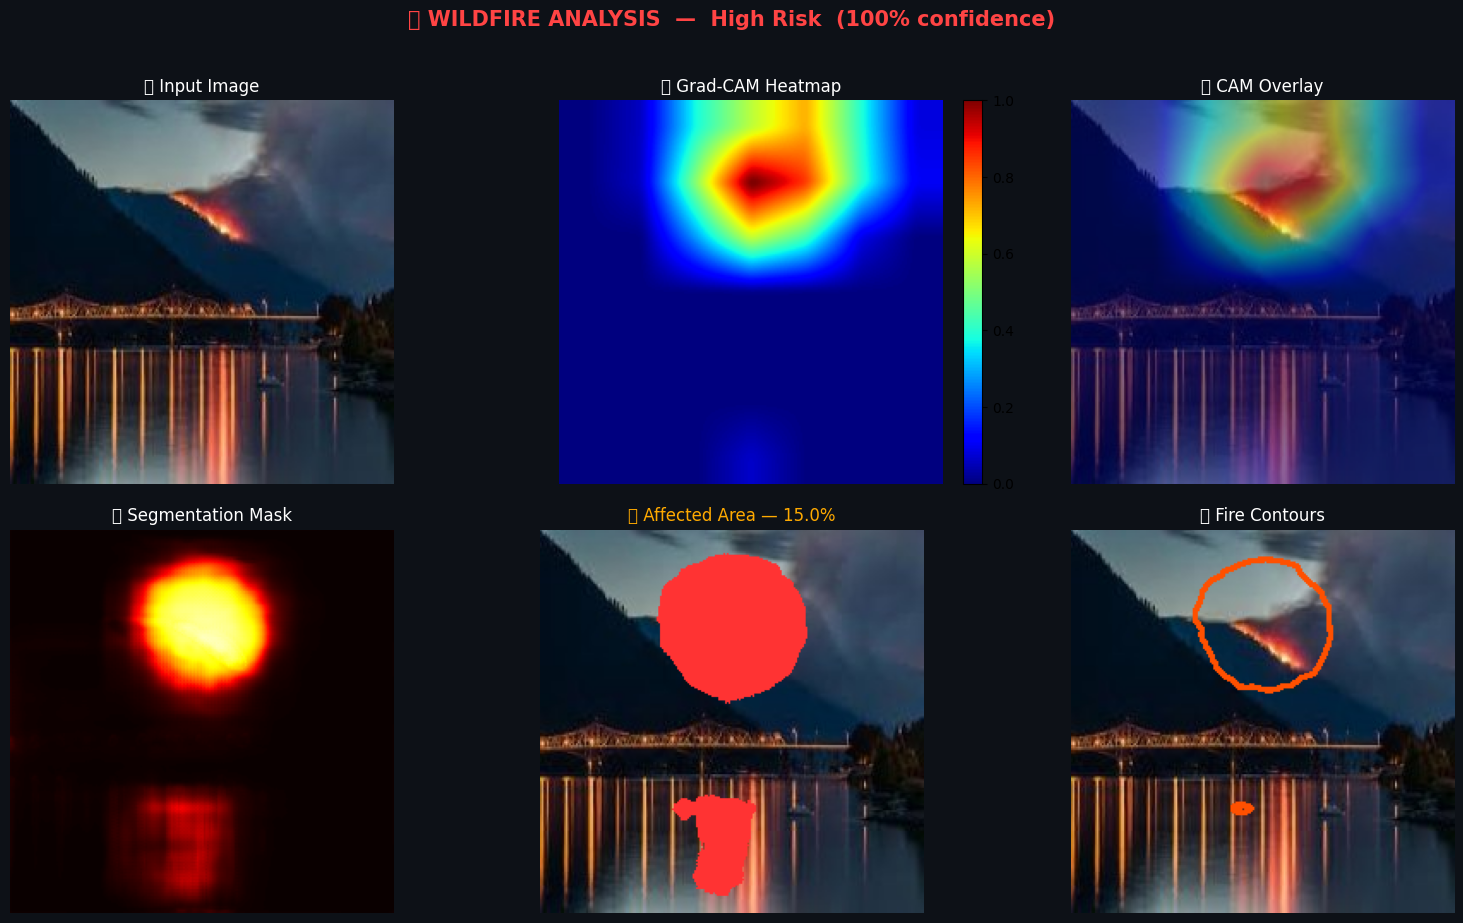


📊 Results:
   risk_level     : High Risk
   class_name     : fire
   confidence     : 99.8%
   affected_area  : 15.0%
   severity       : MODERATE
   num_regions    : 2
   all_probs      : {'fire': '99.8%', 'nofire': '0.0%', 'smoke': '0.2%'}

✅ Analysis pipeline ready!


In [26]:
def analyze_image(img_rgb_uint8):
    img_r  = cv2.resize(img_rgb_uint8, IMG_SIZE)
    inp_e  = ((img_r.astype(np.float32)/127.5) - 1.0)
    inp_u  = img_r.astype(np.float32) / 255.0

    probs  = best_model.predict(inp_e[np.newaxis], verbose=0)[0]
    ci     = int(np.argmax(probs))
    conf   = float(probs[ci])
    name   = CLASS_NAMES[ci]
    risk   = RISK_MAP[name]

    hmap, _ = get_gradcam(inp_e)
    overlay = apply_colormap_overlay(img_r, hmap)

    seg    = unet_model.predict(inp_u[np.newaxis], verbose=0)[0,:,:,0]
    binary = (seg > 0.15).astype(np.float32)
    burnt_pct = float(binary.mean() * 100)

    if   burnt_pct > 50: sev='CRITICAL'; sc='#ff0000'
    elif burnt_pct > 30: sev='SEVERE';   sc='#ff6600'
    elif burnt_pct > 15: sev='MODERATE'; sc='#ffaa00'
    elif burnt_pct >  5: sev='MILD';     sc='#aaff00'
    else:                sev='MINIMAL';  sc='#00ff88'

    seg_u8   = (seg*255).astype(np.uint8)
    _, thr   = cv2.threshold(seg_u8, 76, 255, cv2.THRESH_BINARY)
    cnts, _  = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_img = img_r.copy()
    cv2.drawContours(contour_img, cnts, -1, (255, 80, 0), 2)

    rc = '#ff4444' if risk=='High Risk' else '#FFA500' if risk=='Medium Risk' else '#44ff44'

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(f'🔥 WILDFIRE ANALYSIS  —  {risk}  ({conf:.0%} confidence)',
                 color=rc, fontsize=15, fontweight='bold', y=1.02)

    axes[0,0].imshow(img_rgb_uint8); axes[0,0].set_title('📸 Input Image', color='w'); axes[0,0].axis('off')
    im=axes[0,1].imshow(hmap,cmap='jet',vmin=0,vmax=1); axes[0,1].set_title('🔍 Grad-CAM Heatmap', color='w'); axes[0,1].axis('off')
    plt.colorbar(im, ax=axes[0,1], fraction=0.046, pad=0.04)
    axes[0,2].imshow(overlay); axes[0,2].set_title('🎯 CAM Overlay', color='w'); axes[0,2].axis('off')
    axes[1,0].imshow(seg, cmap='hot', vmin=0, vmax=1); axes[1,0].set_title('🔥 Segmentation Mask', color='w'); axes[1,0].axis('off')
    ov2 = inp_u.copy(); ov2[binary>0.5]=[1,0.2,0.2]
    axes[1,1].imshow(ov2); axes[1,1].set_title(f'🔴 Affected Area — {burnt_pct:.1f}%', color=sc); axes[1,1].axis('off')
    axes[1,2].imshow(contour_img); axes[1,2].set_title('🗺️ Fire Contours', color='w'); axes[1,2].axis('off')

    for ax in axes.flat:
        ax.set_facecolor('#0d1117')
    plt.tight_layout()

    return fig, {
        'risk_level'  : risk,
        'class_name'  : name,
        'confidence'  : f'{conf*100:.1f}%',
        'affected_area': f'{burnt_pct:.1f}%',
        'severity'    : sev,
        'num_regions' : len(cnts),
        'all_probs'   : {CLASS_NAMES[i]: f'{probs[i]*100:.1f}%' for i in range(NUM_CLASSES)}
    }

# Quick test
test_path = p_test[np.random.randint(len(p_test))]
img = cv2.cvtColor(cv2.imread(test_path), cv2.COLOR_BGR2RGB)
fig, results = analyze_image(img)
plt.savefig('/content/analysis_test.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('\n📊 Results:')
for k,v in results.items():
    print(f'   {k:15s}: {v}')
print('\n✅ Analysis pipeline ready!')

## 🎨 Cell 18 — Launch Gradio UI

In [28]:
!pip install -q gradio plotly

import gradio as gr
import plotly.graph_objects as go
from datetime import datetime
import traceback

best_model  = keras.models.load_model('/content/best_final.keras')
unet_model  = keras.models.load_model('/content/best_unet.keras',
                                      custom_objects={'combined_loss': combined_loss})
# Rebuild gradcam model with freshly loaded model


def risk_gauge(conf, risk):
    color = '#ff4444' if risk=='High Risk' else '#FFA500' if risk=='Medium Risk' else '#44ff44'
    fig = go.Figure(go.Indicator(
        mode='gauge+number',
        value=float(conf*100),
        title={'text':f'Risk: {risk}','font':{'color':'white','size':16}},
        number={'font':{'color':'white','size':26},'suffix':'%'},
        gauge={
            'axis':{'range':[0,100],'tickcolor':'white','tickfont':{'color':'white'}},
            'bar':{'color': color},
            'steps':[
                {'range':[0,40],'color':'rgba(46,204,113,0.3)'},
                {'range':[40,70],'color':'rgba(241,196,15,0.3)'},
                {'range':[70,100],'color':'rgba(231,76,60,0.3)'}
            ],
        }
    ))
    fig.update_layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
                      font_color='white', height=250, margin=dict(l=30,r=30,t=50,b=20))
    return fig

def prob_bar(probs):
    colors = ['#ff4444' if RISK_MAP.get(c)=='High Risk'
              else '#FFA500' if RISK_MAP.get(c)=='Medium Risk'
              else '#44ff44' for c in CLASS_NAMES]
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=CLASS_NAMES, y=[float(p*100) for p in probs],
        marker_color=colors,
        text=[f'{p*100:.1f}%' for p in probs],
        textposition='outside', textfont={'color':'white','size':11}
    ))
    fig.update_layout(
        title={'text':'Class Probabilities','font':{'color':'white','size':14}},
        paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(30,30,50,0.8)',
        font_color='white', showlegend=False, height=260,
        margin=dict(l=30,r=30,t=50,b=60),
        yaxis=dict(gridcolor='#444',range=[0,115]),
        xaxis=dict(tickangle=-30)
    )
    return fig

def area_bar(burnt_pct):
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=['🔴 Affected','🟢 Safe'],
        y=[float(burnt_pct), float(100-burnt_pct)],
        marker_color=['#ff4444','#44ff44'],
        text=[f'{burnt_pct:.1f}%',f'{100-burnt_pct:.1f}%'],
        textposition='outside', textfont={'color':'white','size':14}
    ))
    fig.update_layout(
        title={'text':'Area Distribution','font':{'color':'white','size':14}},
        paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(30,30,50,0.8)',
        font_color='white', showlegend=False, height=260,
        margin=dict(l=30,r=30,t=50,b=30),
        yaxis=dict(gridcolor='#444',range=[0,115]),
    )
    return fig

def analyze_ui(image):
    try:
        if image is None:
            return (None, None, None, None, None, '❌ Please upload an image', None)

        img_uint8 = image.astype(np.uint8)
        img_r = cv2.resize(img_uint8, IMG_SIZE)
        inp_e = ((img_r.astype(np.float32)/127.5) - 1.0)
        inp_u = img_r.astype(np.float32) / 255.0

        probs = best_model.predict(inp_e[np.newaxis], verbose=0)[0]
        ci    = int(np.argmax(probs)); conf = float(probs[ci])
        name  = CLASS_NAMES[ci]; risk = RISK_MAP[name]

        hmap, _ = get_gradcam(inp_e)
        cam_overlay = apply_colormap_overlay(img_r, hmap)

        seg    = unet_model.predict(inp_u[np.newaxis], verbose=0)[0,:,:,0]
        binary = (seg > 0.15).astype(np.float32)
        burnt_pct = float(binary.mean() * 100)

        if   burnt_pct > 50: sev='🔴 CRITICAL'
        elif burnt_pct > 30: sev='🟠 SEVERE'
        elif burnt_pct > 15: sev='🟡 MODERATE'
        elif burnt_pct >  5: sev='🟢 MILD'
        else:                sev='⚪ MINIMAL'

        seg_u8  = (seg*255).astype(np.uint8)
        _, thr  = cv2.threshold(seg_u8, 76, 255, cv2.THRESH_BINARY)
        cnts, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_img = img_r.copy()
        cv2.drawContours(contour_img, cnts, -1, (255,80,0), 2)
        seg_overlay = inp_u.copy(); seg_overlay[binary>0.5] = [1,0.2,0.2]
        seg_overlay = (seg_overlay * 255).astype(np.uint8)

        rc = '#ff4444' if risk=='High Risk' else '#FFA500' if risk=='Medium Risk' else '#44ff44'
        prob_str = '  |  '.join([f'{CLASS_NAMES[i]}: {probs[i]*100:.1f}%' for i in range(NUM_CLASSES)])

        status_html = f"""
<div style="background:#111827;padding:20px;border-radius:12px;border:2px solid {rc};font-family:monospace">
  <h2 style="color:{rc};margin:0 0 12px">{risk}</h2>
  <table style="color:white;width:100%;border-collapse:collapse">
    <tr><td style="padding:6px;color:#aaa">Detected</td><td style="padding:6px;font-weight:bold">{name}</td></tr>
    <tr style="background:#1f2937"><td style="padding:6px;color:#aaa">Confidence</td><td style="padding:6px;font-weight:bold">{conf*100:.1f}%</td></tr>
    <tr><td style="padding:6px;color:#aaa">Affected Area</td><td style="padding:6px;font-weight:bold">{burnt_pct:.1f}%</td></tr>
    <tr style="background:#1f2937"><td style="padding:6px;color:#aaa">Severity</td><td style="padding:6px;font-weight:bold">{sev}</td></tr>
    <tr><td style="padding:6px;color:#aaa">Regions</td><td style="padding:6px">{len(cnts)} detected</td></tr>
    <tr style="background:#1f2937"><td style="padding:6px;color:#aaa">All Classes</td><td style="padding:6px;font-size:0.85em">{prob_str}</td></tr>
    <tr><td style="padding:6px;color:#aaa">Time</td><td style="padding:6px">{datetime.now().strftime('%H:%M:%S')}</td></tr>
  </table>
</div>"""

        return (cam_overlay, seg_overlay, contour_img,
                risk_gauge(conf, risk), area_bar(burnt_pct),
                status_html, prob_bar(probs))

    except Exception as e:
        traceback.print_exc()
        return (None,None,None,None,None,
                f'<div style="color:red">❌ Error: {str(e)}</div>',None)

CSS = """
body, .gradio-container { background: #0d1117 !important; color: white !important; }
.gr-button-primary { background: linear-gradient(135deg,#ff4444,#ff8800) !important; border:none !important; font-weight:bold !important; }
h1,h2,h3 { color: #ff6b6b !important; }
"""

with gr.Blocks(css=CSS, title='🔥 Wildfire Intelligence System v5') as demo:
    gr.HTML("""
    <div style="text-align:center;padding:30px;background:linear-gradient(135deg,#1a0a0a,#0d1117);
                border-radius:16px;margin-bottom:20px;border:1px solid #ff444433">
      <h1 style="font-size:2.5em;margin:0;color:#ff6b6b">🔥 Wildfire Intelligence System v5</h1>
      <p style="color:#888;margin:8px 0 0">EfficientNetV2S · 3-Class Detection (Fire / Smoke / No Fire) · Grad-CAM · U-Net Segmentation</p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            inp_img = gr.Image(label='📸 Upload Image', type='numpy', height=300)
            btn     = gr.Button('🚀 Run Analysis', variant='primary', size='lg')
            status  = gr.HTML(value='<div style="color:#888;padding:10px">Ready — Upload an image to begin</div>')

        with gr.Column(scale=2):
            with gr.Tabs():
                with gr.Tab('🎯 Grad-CAM'):
                    cam_out = gr.Image(label='Grad-CAM Overlay', height=300)
                with gr.Tab('🔥 Segmentation'):
                    seg_out = gr.Image(label='Affected Area Overlay', height=300)
                with gr.Tab('🗺️ Contours'):
                    cnt_out = gr.Image(label='Fire Region Contours', height=300)

    with gr.Row():
        gauge_out = gr.Plot(label='Risk Gauge')
        area_out  = gr.Plot(label='Area Distribution')
        prob_out  = gr.Plot(label='Class Probabilities')

    btn.click(fn=analyze_ui, inputs=inp_img,
              outputs=[cam_out, seg_out, cnt_out, gauge_out, area_out, status, prob_out])

    gr.HTML('<hr style="border-color:#333;margin:20px 0">')
    gr.HTML('<p style="text-align:center;color:#555;font-size:0.85em">🔥 Wildfire Intelligence System v5.0 · EfficientNetV2S + U-Net · Proper Grad-CAM · 18,000+ training images</p>')

print('✅ UI built!')

✅ UI built!


## 🚀 Cell 19 — Launch

In [29]:
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://03a3679f7f39fafcd2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 💾 Cell 20 — Save Everything to Drive

In [30]:
save_dir = '/content/drive/MyDrive/Wildfire_System_v5'
os.makedirs(save_dir, exist_ok=True)

best_model.save(f'{save_dir}/risk_model_v5.keras')
unet_model.save(f'{save_dir}/unet_model_v5.keras')
print('✅ Models saved')

for fname in ['training_curves.png','confusion_matrix.png','gradcam_results.png',
              'unet_results.png','samples.png','analysis_test.png']:
    src = f'/content/{fname}'
    if os.path.exists(src):
        shutil.copy(src, save_dir)
        print(f'✅ {fname}')

print(f'\n🎉 Everything saved to {save_dir}')

✅ Models saved
✅ training_curves.png
✅ confusion_matrix.png
✅ gradcam_results.png
✅ unet_results.png
✅ samples.png
✅ analysis_test.png

🎉 Everything saved to /content/drive/MyDrive/Wildfire_System_v5
